# Time of Emergence and SNR

## Imports

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
from scipy import stats
import pickle

## Constants

In [2]:
BASELINE_START, BASELINE_END = 1979, 1995
ANALYSIS_START, ANALYSIS_END = 1979, 2020
SMOOTHING_WINDOW = 10  # years, centered
SNR_THRESHOLD = 2.0
TOE_MIN_CONSECUTIVE_YEARS = 5

## Functions

In [3]:
# Compute annual MHW counts per member, per method
# (duration-weighted: an event counts in EVERY calendar year it is present)
def compute_annual_counts(labels_full, analog_ids_for_method, year_range):
    """
    Returns a DataFrame: rows = years, columns = ensemble members,
    values = number of Blob-analog events present (at all) in that year.
    """
    years = np.arange(year_range[0], year_range[1] + 1)
    counts = pd.DataFrame(0, index=years, columns=range(100))

    for member_id in range(100):
        member_labels = labels_full.isel(ensemble_member=member_id)
        for analog_id in analog_ids_for_method[member_id]:
            mask = (member_labels == analog_id)
            times_present = member_labels.time.where(mask.any(dim=('lat', 'lon')), drop=True)
            if len(times_present) == 0:
                continue
            years_present = np.unique(times_present.dt.year.values)
            for y in years_present:
                if y in counts.index:
                    counts.loc[y, member_id] += 1
    return counts

In [4]:
# Ensemble-mean signal, 10-year centered smoothing
def compute_smoothed_signal(annual_counts, window=SMOOTHING_WINDOW):
    ensemble_mean = annual_counts.mean(axis=1)  # mean across 100 members, per year
    smoothed = ensemble_mean.rolling(window=window, center=True, min_periods=window).mean()
    return ensemble_mean, smoothed

In [5]:
def compute_noise_baseline(annual_counts, baseline_range=(BASELINE_START, BASELINE_END)):
    baseline_data = annual_counts.loc[baseline_range[0]:baseline_range[1]]
    pooled_values = baseline_data.values.flatten()  # every (year, member) pair
    return float(np.std(pooled_values))

In [6]:
def compute_reference_value(smoothed_signal, baseline_range=(BASELINE_START, BASELINE_END)):
    baseline_smoothed = smoothed_signal.loc[baseline_range[0]:baseline_range[1]]
    return float(baseline_smoothed.mean())

In [7]:
def compute_snr(smoothed_signal, reference_value, sigma):
    return np.abs(smoothed_signal - reference_value) / sigma

In [8]:
def find_time_of_emergence(snr_series, threshold=SNR_THRESHOLD, min_consecutive=TOE_MIN_CONSECUTIVE_YEARS):
    above = snr_series >= threshold
    years = snr_series.index.values
    for i in range(len(years) - min_consecutive + 1):
        if above.iloc[i:i + min_consecutive].all():
            return years[i]
    return None

In [9]:
def compute_annual_counts_initiation_only(labels_full, analog_ids_for_method, year_range):
    """
    Returns a DataFrame: rows = years, columns = ensemble members,
    values = number of Blob-analog events INITIATED in that year
    (each event counted exactly once, regardless of duration).
    """
    years = np.arange(year_range[0], year_range[1] + 1)
    counts = pd.DataFrame(0, index=years, columns=range(100))

    for member_id in range(100):
        member_labels = labels_full.isel(ensemble_member=member_id)
        for analog_id in analog_ids_for_method[member_id]:
            mask = (member_labels == analog_id)
            times_present = member_labels.time.where(mask.any(dim=('lat', 'lon')), drop=True)
            if len(times_present) == 0:
                continue
            initiation_year = times_present.dt.year.values[0]
            if initiation_year in counts.index:
                counts.loc[initiation_year, member_id] += 1
    return counts

In [10]:
# Cell area (on the labels/Ocetrac tracking grid)
def compute_cell_area(grid_ref, R=6371.0):
    dlat = np.deg2rad(np.mean(np.diff(grid_ref.lat.values)))
    dlon = np.deg2rad(np.mean(np.diff(grid_ref.lon.values)))
    cell_area = (R ** 2) * dlat * dlon * np.cos(np.deg2rad(grid_ref.lat))
    return xr.DataArray(cell_area.values, coords={'lat': grid_ref.lat}, dims='lat')

In [11]:
# Per-analog stats: duration, intensity_max, extent_max, onset_lat
def get_analog_stats(method, analog_list, ssta_dataset, cell_area_da, ssta_varname):
    stats_list = []
    labels_full = da_mhwobj_labels_by_method[method]
    for member_id, analog_id, first_time in analog_list:
        member_labels = labels_full.isel(ensemble_member=member_id)
        mask = (member_labels == analog_id)
        times_present = member_labels.time.where(mask.any(dim=('lat', 'lon')), drop=True)
        mask_trimmed = mask.sel(time=times_present)

        ssta_da = ssta_dataset[ssta_varname]
        ssta_masked = ssta_da.isel(ensemble_member=member_id).sel(time=times_present).where(mask_trimmed)
        extent_ts = (mask_trimmed.astype(int) * cell_area_da).sum(dim=('lat', 'lon'))

        # Onset latitude: centroid of the FIRST active month's mask
        first_mask = mask.sel(time=times_present.values[0])
        lat2d, lon2d = xr.broadcast(first_mask.lat, first_mask.lon)
        w = first_mask.where(first_mask)
        onset_lat = float((lat2d * w).sum() / w.sum())

        stats_list.append({
            'member_id': member_id,
            'analog_id': analog_id,
            'duration': len(times_present),
            'intensity_max': float(ssta_masked.max()),
            'extent_max': float(extent_ts.max()),
            'onset_lat': onset_lat,
            'onset_month': first_time.dt.month.item(),
        })
    return stats_list

## Load data

In [12]:
base_paths = {
    'linear':    '/glade/work/cmendiola/data_conv_lin_trend',
    'quadratic': '/glade/work/cmendiola/data_quad_trend',
    'ensmean':   '/glade/work/cmendiola/data_ens_mean',
    'noseas':    '/glade/work/cmendiola/data_rm_seasonalcycle_mean',
}
RADIUS_INDEX_FOR_2DEG = 1
OVERLAP_THRESHOLD_INDEX = 4  # 50%

colors = {'linear': 'blue', 'quadratic': 'green', 'ensmean': 'red', 'noseas': 'orange'}
labels_display = {'linear': 'Linear', 'quadratic': 'Quadratic', 'ensmean': 'Ensemble Mean', 'noseas': 'No Seasonality'}

# Load MHW labels and Blob-analog IDs, per method
da_mhwobj_labels_by_method = {}
for method, base_path in base_paths.items():
    mhwobj_paths = [f'{base_path}/ens_{i}_mhwobj.nc' for i in range(100)]
    da_mhwobj = xr.open_mfdataset(mhwobj_paths, combine='nested', concat_dim='ensemble_member')
    da_mhwobj_labels_by_method[method] = (
        da_mhwobj.labels.sel(radius=RADIUS_INDEX_FOR_2DEG)
        .sel(time=slice(f'{ANALYSIS_START}-01', f'{ANALYSIS_END}-12'))
        .compute()
    )
print("Labels loaded:", {m: da_mhwobj_labels_by_method[m].sizes for m in base_paths})

blob_analog_ids = {}
object_id_json_paths = {
    'linear':    'object_id_ls_greenmask_linear_corrected.json',
    'quadratic': 'object_id_ls_greenmask_quadratic_corrected.json',
    'ensmean':   'object_id_ls_greenmask_ensmean_corrected.json',
    'noseas':    'object_id_ls_greenmask_noseas_corrected.json',
}
for method, path in object_id_json_paths.items():
    with open(path, 'r') as f:
        all_thresholds = json.load(f)
    blob_analog_ids[method] = all_thresholds[OVERLAP_THRESHOLD_INDEX]
print({m: sum(len(v) for v in blob_analog_ids[m]) for m in blob_analog_ids}, "-- VERIFY: linear ~331")

Labels loaded: {'linear': Frozen({'ensemble_member': 100, 'time': 504, 'lat': 64, 'lon': 81}), 'quadratic': Frozen({'ensemble_member': 100, 'time': 504, 'lat': 64, 'lon': 81}), 'ensmean': Frozen({'ensemble_member': 100, 'time': 504, 'lat': 64, 'lon': 81}), 'noseas': Frozen({'ensemble_member': 100, 'time': 504, 'lat': 64, 'lon': 81})}
{'linear': 331, 'quadratic': 327, 'ensmean': 312, 'noseas': 343} -- VERIFY: linear ~331


In [13]:
# Load SSTa fields, per method
ssta_notrend_by_method = {}
for method, base_path in base_paths.items():
    ssta_paths = [f'{base_path}/ens_{i}_ssta.nc' for i in range(100)]
    ssta_notrend_by_method[method] = xr.open_mfdataset(ssta_paths, combine='nested', concat_dim='ensemble_member').compute()
print("SSTa loaded:", {m: ssta_notrend_by_method[m].sizes for m in base_paths})

SSTa loaded: {'linear': Frozen({'ensemble_member': 100, 'time': 528, 'lat': 64, 'lon': 81}), 'quadratic': Frozen({'ensemble_member': 100, 'time': 528, 'lat': 64, 'lon': 81}), 'ensmean': Frozen({'ensemble_member': 100, 'time': 528, 'lat': 64, 'lon': 81}), 'noseas': Frozen({'ensemble_member': 100, 'time': 528, 'lat': 64, 'lon': 81})}


## Analysis

### SNR + Time of Emergence

In [14]:
annual_counts_by_method = {}
for method in base_paths:
    annual_counts_by_method[method] = compute_annual_counts(
        da_mhwobj_labels_by_method[method], blob_analog_ids[method], (ANALYSIS_START, ANALYSIS_END)
    )
    print(f"{method}: annual counts computed, shape {annual_counts_by_method[method].shape}")

signal_by_method = {}
for method in base_paths:
    ensemble_mean, smoothed = compute_smoothed_signal(annual_counts_by_method[method])
    signal_by_method[method] = {'ensemble_mean': ensemble_mean, 'smoothed': smoothed}

# Noise baseline (sigma): std of annual counts across ALL
# (member, year) pairs pooled over the 1979-1995 baseline window
noise_baseline_by_method = {method: compute_noise_baseline(annual_counts_by_method[method]) for method in base_paths}
print("\nNoise baselines (sigma):", noise_baseline_by_method)

# Reference value: mean of the SMOOTHED signal over 1979-1995
# (consistent with the baseline window used for sigma)
reference_by_method = {method: compute_reference_value(signal_by_method[method]['smoothed']) for method in base_paths}
print("Reference values (S_1979-1995):", reference_by_method)

linear: annual counts computed, shape (42, 100)
quadratic: annual counts computed, shape (42, 100)
ensmean: annual counts computed, shape (42, 100)
noseas: annual counts computed, shape (42, 100)

Noise baselines (sigma): {'linear': 0.32568054911094113, 'quadratic': 0.345568084518901, 'ensmean': 0.3449381871309358, 'noseas': 0.12516425194678363}
Reference values (S_1979-1995): {'linear': 0.09958333333333334, 'quadratic': 0.11908333333333333, 'ensmean': 0.127, 'noseas': 0.015833333333333335}


In [15]:
# SNR and Time of Emergence
SNR_by_method = {}
ToE_by_method = {}
for method in base_paths:
    snr = compute_snr(signal_by_method[method]['smoothed'], reference_by_method[method], noise_baseline_by_method[method])
    SNR_by_method[method] = snr
    ToE_by_method[method] = find_time_of_emergence(snr)
    print(f"{method}: ToE = {ToE_by_method[method]}, max SNR = {snr.max():.2f}")

years = np.arange(ANALYSIS_START, ANALYSIS_END + 1)

linear: ToE = None, max SNR = 0.31
quadratic: ToE = None, max SNR = 0.20
ensmean: ToE = None, max SNR = 0.11
noseas: ToE = 2008, max SNR = 3.75


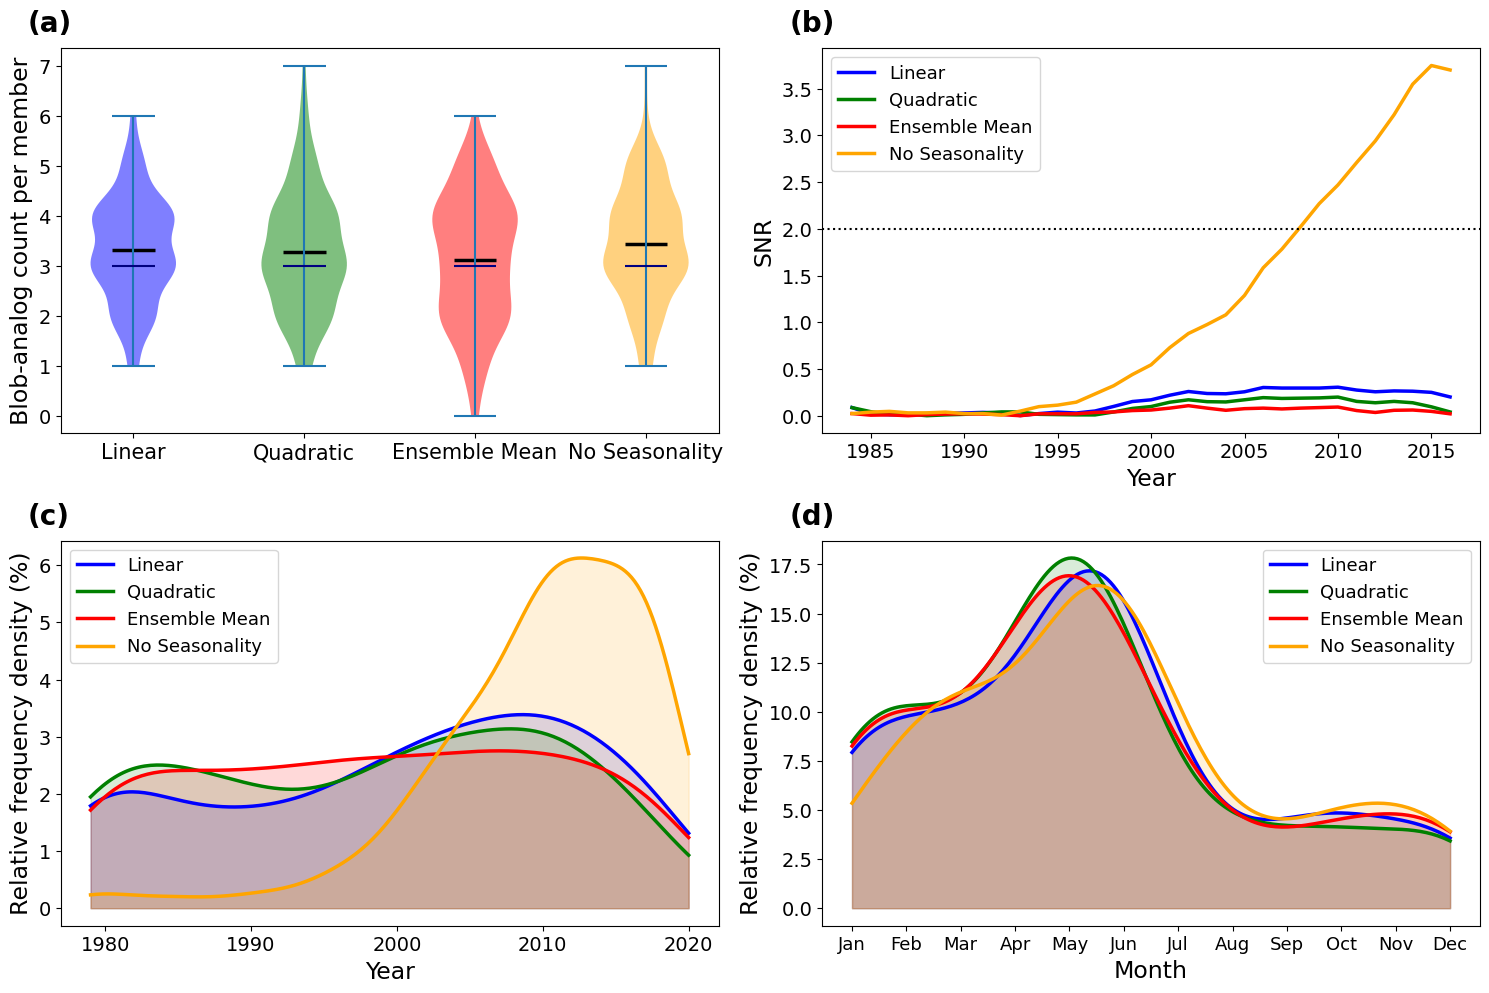

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# (a) Violin plots of Blob-analog counts per member, by method
ax = axes[0, 0]
analog_counts_per_member = {
    method: [len(ids) for ids in blob_analog_ids[method]]
    for method in base_paths
}
data_for_violin = [analog_counts_per_member[m] for m in base_paths]
parts = ax.violinplot(data_for_violin, showmeans=True, showmedians=True, showextrema=True)

for i, method in enumerate(base_paths):
    parts['bodies'][i].set_facecolor(colors[method])
    parts['bodies'][i].set_alpha(0.5)
parts['cmeans'].set_color('black')
parts['cmeans'].set_linewidth(2.5)
parts['cmedians'].set_color('navy')
parts['cmedians'].set_linewidth(1.5)

ax.set_xticks(range(1, len(base_paths) + 1))
ax.set_xticklabels([labels_display[m] for m in base_paths], fontsize=15)
ax.set_ylabel('Blob-analog count per member', fontsize=17)
ax.tick_params(axis='y', labelsize=14)
ax.text(-0.05, 1.10, '(a)', transform=ax.transAxes, fontsize=20, fontweight='bold', va='top')

# (b) SNR for annual MHW frequency, relative to 1979-1995
ax = axes[0, 1]
for method in base_paths:
    ax.plot(years, SNR_by_method[method].values, label=labels_display[method], color=colors[method], linewidth=2.5)

ax.axhline(SNR_THRESHOLD, color='black', linestyle=':', linewidth=1.5)
ax.set_xlabel('Year', fontsize=17)
ax.set_ylabel('SNR', fontsize=17)
ax.tick_params(labelsize=14)
ax.legend(fontsize=13, loc='upper left')
ax.text(-0.05, 1.10, '(b)', transform=ax.transAxes, fontsize=20, fontweight='bold', va='top')

# (c) KDE of Blob-analog initial-detection YEAR
ax = axes[1, 0]
for method in base_paths:
    all_init_years = []
    labels_full = da_mhwobj_labels_by_method[method]
    for member_id in range(100):
        member_labels = labels_full.isel(ensemble_member=member_id)
        for analog_id in blob_analog_ids[method][member_id]:
            first_time = member_labels.time.where((member_labels == analog_id).any(dim=('lat', 'lon')), drop=True)[0]
            all_init_years.append(first_time.dt.year.item())

    if len(all_init_years) > 1:
        kde = stats.gaussian_kde(all_init_years)
        x = np.linspace(ANALYSIS_START, ANALYSIS_END, 200)
        y = kde(x)
        y_pct = 100 * y / np.trapz(y, x)
        ax.plot(x, y_pct, label=labels_display[method], color=colors[method], linewidth=2.5)
        ax.fill_between(x, y_pct, alpha=0.15, color=colors[method])

ax.set_xlabel('Year', fontsize=17)
ax.set_ylabel('Relative frequency density (%)', fontsize=17)
ax.tick_params(labelsize=14)
ax.legend(fontsize=13)
ax.text(-0.05, 1.10, '(c)', transform=ax.transAxes, fontsize=20, fontweight='bold', va='top')

# (d) KDE of Blob-analog initial-detection MONTH
ax = axes[1, 1]
for method in base_paths:
    all_init_months = []
    labels_full = da_mhwobj_labels_by_method[method]
    for member_id in range(100):
        member_labels = labels_full.isel(ensemble_member=member_id)
        for analog_id in blob_analog_ids[method][member_id]:
            first_time = member_labels.time.where((member_labels == analog_id).any(dim=('lat', 'lon')), drop=True)[0]
            all_init_months.append(first_time.dt.month.item())

    if len(all_init_months) > 1:
        kde = stats.gaussian_kde(all_init_months)
        x = np.linspace(1, 12, 200)
        y = kde(x)
        y_pct = 100 * y / np.trapz(y, x)
        ax.plot(x, y_pct, label=labels_display[method], color=colors[method], linewidth=2.5)
        ax.fill_between(x, y_pct, alpha=0.15, color=colors[method])

ax.set_xlabel('Month', fontsize=17)
ax.set_ylabel('Relative frequency density (%)', fontsize=17)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], fontsize=13)
ax.tick_params(axis='y', labelsize=14)
ax.legend(fontsize=13)
ax.text(-0.05, 1.10, '(d)', transform=ax.transAxes, fontsize=20, fontweight='bold', va='top')

plt.tight_layout()
plt.show()

In [17]:
# Alternative counting scheme: count each event ONLY in its
# initiation year (not every year it's present)

annual_counts_initiation_by_method = {}
signal_initiation_by_method = {}
noise_baseline_initiation_by_method = {}
reference_initiation_by_method = {}
SNR_initiation_by_method = {}
ToE_initiation_by_method = {}

for method in base_paths:
    counts = compute_annual_counts_initiation_only(
        da_mhwobj_labels_by_method[method], blob_analog_ids[method], (ANALYSIS_START, ANALYSIS_END)
    )
    annual_counts_initiation_by_method[method] = counts

    ensemble_mean, smoothed = compute_smoothed_signal(counts)
    signal_initiation_by_method[method] = {'ensemble_mean': ensemble_mean, 'smoothed': smoothed}

    sigma = compute_noise_baseline(counts)
    noise_baseline_initiation_by_method[method] = sigma

    ref = compute_reference_value(smoothed)
    reference_initiation_by_method[method] = ref

    snr = compute_snr(smoothed, ref, sigma)
    SNR_initiation_by_method[method] = snr

    toe = find_time_of_emergence(snr)
    ToE_initiation_by_method[method] = toe

    print(f"{method}: ToE(initiation-only) = {toe}, max SNR = {snr.max():.2f} "
          f"| ToE(every-year-present) = {ToE_by_method[method]}, max SNR = {SNR_by_method[method].max():.2f}")

linear: ToE(initiation-only) = None, max SNR = 0.21 | ToE(every-year-present) = None, max SNR = 0.31
quadratic: ToE(initiation-only) = None, max SNR = 0.11 | ToE(every-year-present) = None, max SNR = 0.20
ensmean: ToE(initiation-only) = None, max SNR = 0.04 | ToE(every-year-present) = None, max SNR = 0.11
noseas: ToE(initiation-only) = None, max SNR = 1.93 | ToE(every-year-present) = 2008, max SNR = 3.75


## Comparing metrics

In [18]:
with open('/glade/derecho/scratch/cassiacai/section_3_2_analog_data.pkl', 'rb') as f:
    save_bundle = pickle.load(f)

all_analog_characteristics = save_bundle['all_analog_characteristics']
blob_fosi_characteristics = save_bundle['blob_fosi_characteristics']

print(f"Loaded {len(all_analog_characteristics)} analogs -- VERIFY: 331")

Loaded 331 analogs -- VERIFY: 331


In [19]:
# Reload MHW labels and Blob-analog IDs (linear method)
base_path_linear = '/glade/work/cmendiola/data_conv_lin_trend'
RADIUS_INDEX_FOR_2DEG = 1
OVERLAP_THRESHOLD_INDEX = 4

mhwobj_paths = [f'{base_path_linear}/ens_{i}_mhwobj.nc' for i in range(100)]
da_mhwobj = xr.open_mfdataset(mhwobj_paths, combine='nested', concat_dim='ensemble_member')
labels_full = da_mhwobj.labels.sel(radius=RADIUS_INDEX_FOR_2DEG).sel(time=slice('1979-01', '2020-12')).compute()
print("Labels loaded:", labels_full.sizes)

with open('object_id_ls_greenmask_linear_corrected.json', 'r') as f:
    linear_all_thresholds = json.load(f)
blob_analog_ids = {'linear': linear_all_thresholds[OVERLAP_THRESHOLD_INDEX]}
print(f"Total linear analogs: {sum(len(a) for a in blob_analog_ids['linear'])} -- VERIFY: 331")

Labels loaded: Frozen({'ensemble_member': 100, 'time': 504, 'lat': 64, 'lon': 81})
Total linear analogs: 331 -- VERIFY: 331


In [20]:
# Compute onset month and onset latitude for each analog
onset_info = {}
for member_id in range(100):
    member_labels = labels_full.isel(ensemble_member=member_id)
    for analog_id in blob_analog_ids['linear'][member_id]:
        key = (member_id, analog_id)
        if key not in all_analog_characteristics:
            continue
        mask = (member_labels == analog_id)
        times_present = member_labels.time.where(mask.any(dim=('lat', 'lon')), drop=True)
        if len(times_present) == 0:
            continue
        first_time = times_present.values[0]
        onset_month = first_time.month if hasattr(first_time, 'month') else int(np.datetime64(first_time, 'M').astype(object).month)

        first_mask = mask.sel(time=first_time)
        lat_grid, lon_grid = xr.broadcast(first_mask.lat, first_mask.lon)
        onset_lat = float(lat_grid.where(first_mask).mean())

        onset_info[key] = {'onset_month': onset_month, 'onset_lat': onset_lat}

print(f"Onset info computed for {len(onset_info)} analogs -- VERIFY: 331")

# ============================================================
# Group by season, compute duration/extent/intensity stats + t-tests
# ============================================================
season_map = {12: 'winter', 1: 'winter', 2: 'winter', 3: 'spring', 4: 'spring', 5: 'spring',
              6: 'summer', 7: 'summer', 8: 'summer', 9: 'fall', 10: 'fall', 11: 'fall'}

seasons = ['winter', 'spring', 'summer']
stats_by_season = {}
for season in seasons:
    keys_in_season = [k for k, v in onset_info.items() if season_map[v['onset_month']] == season]
    durations = np.array([all_analog_characteristics[k]['duration'] for k in keys_in_season])
    extents = np.array([all_analog_characteristics[k]['extent_max'] for k in keys_in_season])
    intensities = np.array([all_analog_characteristics[k]['intensity_max'] for k in keys_in_season])
    lats = np.array([onset_info[k]['onset_lat'] for k in keys_in_season])

    stats_by_season[season] = {
        'n': len(durations),
        'duration_mean': durations.mean(), 'duration_std': durations.std(),
        'extent_mean': extents.mean(), 'extent_std': extents.std(),
        'intensity_mean': intensities.mean(), 'intensity_std': intensities.std(),
        'lat_mean': lats.mean(),
        'intensity_vals': intensities,
    }

print("\n=== Seasonal characteristics (linear detrending) ===")
for season in seasons:
    s = stats_by_season[season]
    print(f"{season}: n={s['n']}, duration={s['duration_mean']:.1f}±{s['duration_std']:.1f} months, "
          f"extent={s['extent_mean']:.1f}±{s['extent_std']:.1f} M km², "
          f"intensity={s['intensity_mean']:.2f}±{s['intensity_std']:.2f}°C, "
          f"onset_lat={s['lat_mean']:.1f}°N")

t_ws, p_ws = stats.ttest_ind(stats_by_season['winter']['intensity_vals'], stats_by_season['spring']['intensity_vals'], equal_var=False)
t_ss, p_ss = stats.ttest_ind(stats_by_season['spring']['intensity_vals'], stats_by_season['summer']['intensity_vals'], equal_var=False)
print(f"\nWinter vs spring intensity: p={p_ws:.4f}")
print(f"Spring vs summer intensity: p={p_ss:.4f}")

Onset info computed for 331 analogs -- VERIFY: 331

=== Seasonal characteristics (linear detrending) ===
winter: n=80, duration=16.4±7.3 months, extent=20580972.2±5097443.5 M km², intensity=4.26±1.77°C, onset_lat=31.2°N
spring: n=122, duration=13.6±7.3 months, extent=18584924.4±4437903.8 M km², intensity=3.63±1.24°C, onset_lat=35.7°N
summer: n=87, duration=9.2±6.3 months, extent=16287572.4±4834396.5 M km², intensity=3.44±1.19°C, onset_lat=44.0°N

Winter vs spring intensity: p=0.0073
Spring vs summer intensity: p=0.2711


In [21]:
# Compare linear trend within the 1979-1995 baseline window
# vs. the full 1979-2020 record, for each method
for method in base_paths:
    ensemble_mean = signal_by_method[method]['ensemble_mean']

    baseline_years = ensemble_mean.loc[BASELINE_START:BASELINE_END].index.values
    baseline_vals = ensemble_mean.loc[BASELINE_START:BASELINE_END].values
    slope_baseline, intercept, r, p_baseline, se = stats.linregress(baseline_years, baseline_vals)

    full_years = ensemble_mean.index.values
    full_vals = ensemble_mean.values
    slope_full, intercept_f, r_f, p_full, se_f = stats.linregress(full_years, full_vals)

    ratio = abs(slope_baseline / slope_full) if slope_full != 0 else np.nan

    print(f"\n{method}:")
    print(f"  Baseline (1979-95) trend: {slope_baseline:.5f} events/year (p={p_baseline:.3f})")
    print(f"  Full-record (1979-2020) trend: {slope_full:.5f} events/year (p={p_full:.3f})")
    print(f"  Ratio (baseline/full): {ratio:.2f}")


linear:
  Baseline (1979-95) trend: -0.00765 events/year (p=0.012)
  Full-record (1979-2020) trend: 0.00146 events/year (p=0.064)
  Ratio (baseline/full): 5.24

quadratic:
  Baseline (1979-95) trend: -0.00723 events/year (p=0.003)
  Full-record (1979-2020) trend: -0.00013 events/year (p=0.856)
  Ratio (baseline/full): 55.42

ensmean:
  Baseline (1979-95) trend: -0.00211 events/year (p=0.031)
  Full-record (1979-2020) trend: 0.00005 events/year (p=0.911)
  Ratio (baseline/full): 44.09

noseas:
  Baseline (1979-95) trend: -0.00015 events/year (p=0.791)
  Full-record (1979-2020) trend: 0.01440 events/year (p=0.000)
  Ratio (baseline/full): 0.01


In [27]:
OVERLAP_THRESHOLD_INDEX = 4  # 50%

object_id_json_paths = {
    'linear':    'object_id_ls_greenmask_linear_corrected.json',
    'quadratic': 'object_id_ls_greenmask_quadratic_corrected.json',
    'ensmean':   'object_id_ls_greenmask_ensmean_corrected.json',
    'noseas':    'object_id_ls_greenmask_noseas_corrected.json',
}

blob_analog_ids = {}
for method, path in object_id_json_paths.items():
    with open(path, 'r') as f:
        all_thresholds = json.load(f)
    blob_analog_ids[method] = all_thresholds[OVERLAP_THRESHOLD_INDEX]

print({m: sum(len(v) for v in blob_analog_ids[m]) for m in blob_analog_ids},
      "-- VERIFY: linear=331, quadratic=327, ensmean=312, noseas=343")

cell_area_da = compute_cell_area(da_mhwobj_labels_by_method['linear'])


{'linear': 331, 'quadratic': 327, 'ensmean': 312, 'noseas': 343} -- VERIFY: linear=331, quadratic=327, ensmean=312, noseas=343


In [28]:
ssta_varnames = {
    'linear': '__xarray_dataarray_variable__',
    'quadratic': '__xarray_dataarray_variable__',
    'ensmean': 'SST',
    'noseas': '__xarray_dataarray_variable__',
}

# ============================================================
# Now the season-classification + stats loop can reference it
# ============================================================
seasonal_stats_all_methods = {}
for method in base_paths:
    labels_full_m = da_mhwobj_labels_by_method[method]
    winter_analogs_m, spring_analogs_m, summer_analogs_m, fall_analogs_m = [], [], [], []
    for member_id in range(100):
        member_labels = labels_full_m.isel(ensemble_member=member_id)
        for analog_id in blob_analog_ids[method][member_id]:
            first_time = member_labels.time.where((member_labels == analog_id).any(dim=('lat', 'lon')), drop=True)[0]
            month = first_time.dt.month.item()
            if month in [12, 1, 2]:
                winter_analogs_m.append((member_id, analog_id, first_time))
            elif month in [3, 4, 5]:
                spring_analogs_m.append((member_id, analog_id, first_time))
            elif month in [6, 7, 8]:
                summer_analogs_m.append((member_id, analog_id, first_time))
            elif month in [9, 10, 11]:
                fall_analogs_m.append((member_id, analog_id, first_time))

    varname = ssta_varnames[method]  # now defined before this line runs
    winter_s = get_analog_stats(method, winter_analogs_m, ssta_notrend_by_method[method], cell_area_da, varname)
    spring_s = get_analog_stats(method, spring_analogs_m, ssta_notrend_by_method[method], cell_area_da, varname)
    summer_s = get_analog_stats(method, summer_analogs_m, ssta_notrend_by_method[method], cell_area_da, varname)
    fall_s = get_analog_stats(method, fall_analogs_m, ssta_notrend_by_method[method], cell_area_da, varname)

    seasonal_stats_all_methods[method] = {'winter': winter_s, 'spring': spring_s, 'summer': summer_s, 'fall': fall_s}

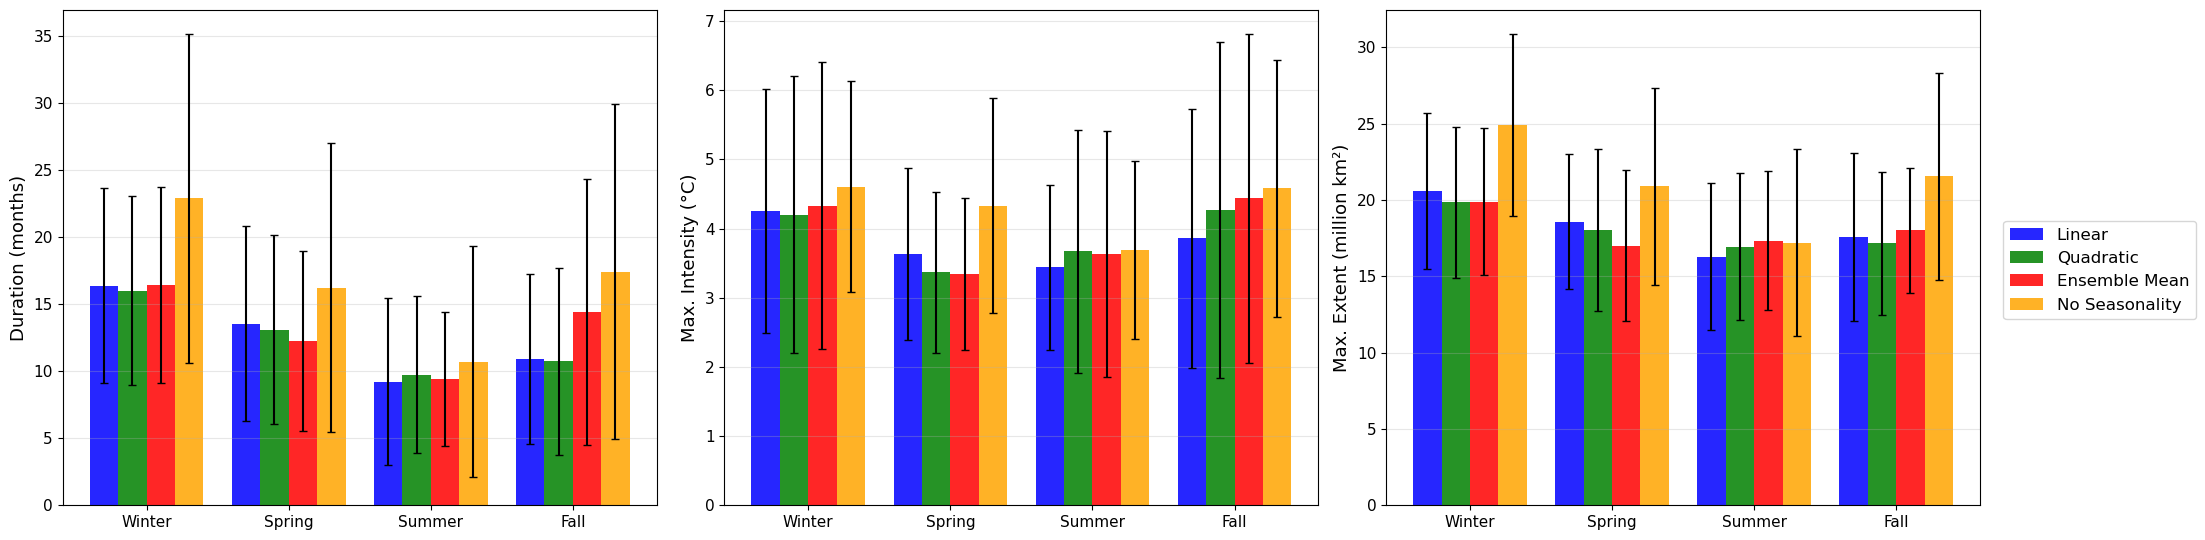

In [29]:
seasons = ['winter', 'spring', 'summer', 'fall']
method_order = ['linear', 'quadratic', 'ensmean', 'noseas']

fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))

metrics = [
    ('duration', 'Duration (months)', axes[0]),
    ('intensity_max', 'Max. Intensity (°C)', axes[1]),
    ('extent_max', 'Max. Extent (million km²)', axes[2]),
]

width = 0.2
x = np.arange(len(seasons))

handles_for_legend = None
for metric_key, ylabel, ax in metrics:
    for i, method in enumerate(method_order):
        means, stds = [], []
        for season in seasons:
            vals = np.array([s[metric_key] for s in seasonal_stats_all_methods[method][season]])
            if metric_key == 'extent_max':
                vals = vals / 1e6
            means.append(vals.mean())
            stds.append(vals.std())
        bars = ax.bar(x + i * width, means, width, yerr=stds, capsize=3,
                       label=labels_display[method], color=colors[method], alpha=0.85)
        if ax == axes[0]:
            pass  # legend handles collected below via axes[0]

    ax.set_xticks(x + 1.5 * width)
    ax.set_xticklabels([s.capitalize() for s in seasons], fontsize=13)
    ax.set_ylabel(ylabel, fontsize=13)
    ax.tick_params(labelsize=11)
    ax.grid(axis='y', alpha=0.3)

# Single shared legend, placed outside to the right of the whole figure
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, fontsize=12, loc='center left', bbox_to_anchor=(1.0, 0.5))

plt.tight_layout()
plt.show()

In [31]:
# Build all_durations_flat from seasonal_stats_all_methods
method_order = ['linear', 'quadratic', 'ensmean', 'noseas']
seasons = ['winter', 'spring', 'summer', 'fall']

all_durations_flat = []
for method in method_order:
    for season in seasons:
        for s in seasonal_stats_all_methods[method][season]:
            all_durations_flat.append((method, season, s['member_id'], s['analog_id'], s['duration']))

all_durations_flat.sort(key=lambda x: -x[4])  # sort descending by duration

print(f"Total analogs in all_durations_flat: {len(all_durations_flat)}")
print("\nTop 15 longest-duration analogs:")
for method, season, member_id, analog_id, duration in all_durations_flat[:15]:
    print(f"  {method} / {season}: member={member_id}, analog_id={analog_id}, duration={duration} months")

Total analogs in all_durations_flat: 1313

Top 15 longest-duration analogs:
  noseas / spring: member=86, analog_id=45.0, duration=73 months
  noseas / fall: member=32, analog_id=50.0, duration=73 months
  noseas / spring: member=22, analog_id=48.0, duration=57 months
  noseas / winter: member=29, analog_id=14.0, duration=51 months
  ensmean / fall: member=32, analog_id=73.0, duration=50 months
  noseas / winter: member=7, analog_id=38.0, duration=50 months
  noseas / fall: member=93, analog_id=74.0, duration=50 months
  noseas / winter: member=17, analog_id=71.0, duration=49 months
  noseas / winter: member=31, analog_id=44.0, duration=48 months
  noseas / winter: member=9, analog_id=29.0, duration=47 months
  noseas / winter: member=16, analog_id=59.0, duration=47 months
  noseas / winter: member=57, analog_id=55.0, duration=46 months
  noseas / spring: member=90, analog_id=47.0, duration=45 months
  noseas / winter: member=63, analog_id=67.0, duration=44 months
  noseas / summer: me